# ARC-v0.4 — Statistical Mechanism Audit

## Purpose

ARC-v0.3 produced a strong preliminary mechanism result:

- PQ32↔SQ8 query-state divergence increased with feedback depth;
- candidate-set divergence increased with feedback depth;
- absolute utility gap increased with feedback depth;
- replacing PQ32 feedback with SQ8 feedback improved final nDCG;
- retrieval-fidelity effects followed the expected PQ32 → PQ64 → SQ8 ordering.

Before spending compute on cross-dataset replication, this notebook tries to **falsify**
that result statistically.

No retrieval is run here.

It only reads the persisted ARC-v0.3 evidence.

---

## Primary audit questions

### Q1 — Is amplification positive at the query level?

For each query/configuration, estimate the slope across feedback rounds:

\[
D_q(t)=a_q+b_qt
\]

\[
\Delta D_C(t)
=
D_C(t)-D_C(0)
\]

\[
|\Delta U(t)|=c_q+d_qt.
\]

Then test:

\[
E[b_q] > 0,\qquad
E[d_q] > 0.
\]

This avoids relying only on a slope fitted to aggregate means.

### Q2 — Is the intervention effect statistically stable?

For every paired query:

\[
\Delta_i
=
U_i(
PQ32\ search\rightarrow SQ8\ feedback
)
-
U_i(
PQ32\rightarrow PQ32\ feedback
).
\]

We report:

- paired mean;
- median;
- percentile distribution;
- query-cluster bootstrap CI;
- paired sign-flip randomization p-value;
- fraction positive / negative / exactly unchanged.

### Q3 — Is the mean driven by a tiny number of queries?

We measure:

- top 1%, 5%, 10% contribution to positive effect mass;
- effective number of contributing queries;
- effect among initially harmed trajectories;
- rescue-to-baseline rate.

### Q4 — Does the result hold for both feedback operators?

Mean and softmax are audited separately.

### Q5 — Does candidate divergence still amplify after removing the huge \(t=0\)
retriever mismatch?

Primary candidate metric becomes:

\[
\boxed{
D_C(t)-D_C(0)
}
\]

rather than raw candidate divergence.

---

## Statistical unit

**Query is the primary independent unit.**

When multiple feedback configurations exist for the same query, the primary pooled analysis
first averages effects within query. This prevents treating repeated trajectories of the same
query as independent samples.

Method-specific results are reported separately as robustness analyses.


In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
from pathlib import Path
from datetime import datetime
import json, math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260816
BOOTSTRAP_SAMPLES = 20_000
RANDOMIZATION_SAMPLES = 100_000
EPS = 1e-12

ARC_ROOT = Path(
    "/content/drive/MyDrive/rag-pq-checkpoints/arc-v0"
)

V03_RUNS = sorted(
    [
        p for p in ARC_ROOT.glob("error-amplification-v03-*")
        if (p/"report.json").is_file()
        and (p/"paired_trajectory_divergence.parquet").is_file()
        and (p/"feedback_intervention.parquet").is_file()
    ],
    key=lambda p:p.stat().st_mtime,
)

if not V03_RUNS:
    raise FileNotFoundError(
        "No completed ARC-v0.3 run with persisted evidence found."
    )

V03_RUN = V03_RUNS[-1]

OUT = ARC_ROOT / (
    "statistical-mechanism-audit-v04-"
    + datetime.now().strftime("%Y%m%d-%H%M%S")
)
OUT.mkdir(parents=True, exist_ok=True)

print("Source v0.3:", V03_RUN)
print("Output     :", OUT)


Source v0.3: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/error-amplification-v03-20260815-201450
Output     : /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/statistical-mechanism-audit-v04-20260815-202739


## 1. Load v0.3 evidence and verify protocol


In [3]:
with open(V03_RUN/"report.json","r",encoding="utf-8") as f:
    v03_report = json.load(f)

assert v03_report.get("test_retrieval_performed") is False

pair_df = pd.read_parquet(
    V03_RUN/"paired_trajectory_divergence.parquet"
)

intervention_df = pd.read_parquet(
    V03_RUN/"feedback_intervention.parquet"
)

v03_slopes = pd.read_csv(
    V03_RUN/"amplification_slopes.csv"
)

v03_intervention_summary = pd.read_csv(
    V03_RUN/"feedback_intervention_summary.csv"
)

print("paired divergence rows :", len(pair_df))
print("intervention rows      :", len(intervention_df))
print("unique paired queries  :", pair_df["query_id"].nunique())
print("unique intervention q  :", intervention_df["query_id"].nunique())
print("methods                :", sorted(pair_df["method"].unique()))
print("iterations             :", sorted(pair_df["iteration"].unique()))

display(v03_slopes)


paired divergence rows : 45000
intervention rows      : 45000
unique paired queries  : 1500
unique intervention q  : 1500
methods                : ['mean', 'softmax']
iterations             : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,condition_a,condition_b,metric,slope_per_iteration,t0,t_final,final_over_t0
0,ivfpq32,ivfpq64,mean_query_divergence,0.003108,-4.748503e-08,0.014194,-298906.000000
1,ivfpq32,ivfpq64,mean_candidate_divergence,0.003164,7.591334e-01,0.774053,1.019653
2,ivfpq32,ivfpq64,mean_abs_utility_gap,0.004870,2.118977e-02,0.041777,1.971561
3,ivfpq32,ivfsq8,mean_query_divergence,0.003694,-4.748503e-08,0.016535,-348204.751046
4,ivfpq32,ivfsq8,mean_candidate_divergence,0.007529,7.540154e-01,0.787932,1.044981
5,ivfpq32,ivfsq8,mean_abs_utility_gap,0.005672,2.188904e-02,0.045873,2.095719
6,ivfpq64,ivfsq8,mean_query_divergence,0.001952,-4.748503e-08,0.008803,-185375.836402
7,ivfpq64,ivfsq8,mean_candidate_divergence,0.008097,5.610329e-01,0.597779,1.065497
8,ivfpq64,ivfsq8,mean_abs_utility_gap,0.001954,8.294985e-03,0.016195,1.952339


## 2. Statistical helpers


In [4]:
def paired_bootstrap_mean(
    values,
    samples=BOOTSTRAP_SAMPLES,
    seed=SEED,
):
    x = np.asarray(values, np.float64)
    x = x[np.isfinite(x)]

    rng = np.random.default_rng(seed)
    n = len(x)

    draws = np.empty(samples, dtype=np.float64)

    for b in range(samples):
        idx = rng.integers(0,n,n)
        draws[b] = x[idx].mean()

    return {
        "n": int(n),
        "mean": float(x.mean()),
        "median": float(np.median(x)),
        "ci_low": float(np.quantile(draws,.025)),
        "ci_high": float(np.quantile(draws,.975)),
        "bootstrap_p_gt_0": float(np.mean(draws <= 0)),
    }

def sign_flip_randomization(
    values,
    samples=RANDOMIZATION_SAMPLES,
    seed=SEED,
    alternative="greater",
):
    x = np.asarray(values, np.float64)
    x = x[np.isfinite(x)]

    obs = float(x.mean())
    rng = np.random.default_rng(seed)

    exceed = 0

    # Chunked to keep memory tiny.
    for _ in range(samples):
        signs = rng.choice(
            np.array([-1.0,1.0]),
            size=len(x),
        )
        stat = float(np.mean(x*signs))

        if alternative == "greater":
            exceed += stat >= obs
        elif alternative == "two-sided":
            exceed += abs(stat) >= abs(obs)
        else:
            raise ValueError(alternative)

    return (exceed+1)/(samples+1)

def holm_adjust(pvalues):
    p = np.asarray(pvalues, np.float64)
    m = len(p)

    order = np.argsort(p)
    adjusted = np.empty(m, dtype=np.float64)

    running = 0.0

    for rank, idx in enumerate(order):
        raw = (m-rank)*p[idx]
        running = max(running, raw)
        adjusted[idx] = min(running,1.0)

    return adjusted

def query_linear_slope(g, metric):
    g = g.sort_values("iteration")
    x = g["iteration"].to_numpy(np.float64)
    y = g[metric].to_numpy(np.float64)

    if len(np.unique(x)) < 2:
        return np.nan

    return float(np.polyfit(x,y,1)[0])

def effect_quantiles(x):
    x = np.asarray(x,np.float64)
    return {
        "p00":float(np.quantile(x,0)),
        "p01":float(np.quantile(x,.01)),
        "p05":float(np.quantile(x,.05)),
        "p10":float(np.quantile(x,.10)),
        "p25":float(np.quantile(x,.25)),
        "p50":float(np.quantile(x,.50)),
        "p75":float(np.quantile(x,.75)),
        "p90":float(np.quantile(x,.90)),
        "p95":float(np.quantile(x,.95)),
        "p99":float(np.quantile(x,.99)),
        "p100":float(np.quantile(x,1)),
    }

def contribution_concentration(x):
    x = np.asarray(x,np.float64)
    pos = np.sort(x[x>0])[::-1]

    if len(pos)==0 or pos.sum() <= 0:
        return {
            "positive_queries":0,
            "top1pct_mass":np.nan,
            "top5pct_mass":np.nan,
            "top10pct_mass":np.nan,
            "effective_positive_n":0.0,
        }

    total = pos.sum()

    def frac_mass(frac):
        k=max(1,int(np.ceil(len(pos)*frac)))
        return float(pos[:k].sum()/total)

    # Inverse-Herfindahl effective contributor count.
    w=pos/total
    effective_n=float(1.0/np.sum(w*w))

    return {
        "positive_queries":int(len(pos)),
        "top1pct_mass":frac_mass(.01),
        "top5pct_mass":frac_mass(.05),
        "top10pct_mass":frac_mass(.10),
        "effective_positive_n":effective_n,
    }


## 3. Query-level amplification slopes

Primary pair:

\[
PQ32 \leftrightarrow SQ8.
\]

For candidate divergence we first remove the large one-shot mismatch:

\[
D_C^{incremental}(t)
=
D_C(t)-D_C(0).
\]

For every query and feedback method we estimate slopes for:

- query divergence;
- incremental candidate divergence;
- absolute utility gap.

Then the **primary pooled analysis averages slopes across feedback methods within query**.


In [5]:
pq_sq = pair_df[
    (pair_df["condition_a"]=="ivfpq32")
    & (pair_df["condition_b"]=="ivfsq8")
].copy()

# Baseline-normalize candidate divergence per query/config.
config_cols = [
    "query_id",
    "method",
    "k_feedback",
    "alpha",
    "temperature",
]

baseline_c = (
    pq_sq[pq_sq["iteration"]==0]
    [config_cols+["candidate_divergence"]]
    .rename(
        columns={
            "candidate_divergence":
            "candidate_divergence_t0"
        }
    )
)

pq_sq = pq_sq.merge(
    baseline_c,
    on=config_cols,
    how="left",
    validate="many_to_one",
)

pq_sq["candidate_divergence_increment"] = (
    pq_sq["candidate_divergence"]
    - pq_sq["candidate_divergence_t0"]
)

pq_sq["abs_utility_gap"] = np.abs(
    pq_sq["utility_gap_b_minus_a"]
)

slope_rows = []

for key,g in pq_sq.groupby(
    config_cols,
    dropna=False,
):
    slope_rows.append({
        "query_id":key[0],
        "method":key[1],
        "k_feedback":key[2],
        "alpha":key[3],
        "temperature":key[4],
        "query_divergence_slope":
            query_linear_slope(g,"query_divergence"),
        "candidate_increment_slope":
            query_linear_slope(g,"candidate_divergence_increment"),
        "abs_utility_gap_slope":
            query_linear_slope(g,"abs_utility_gap"),
    })

query_method_slopes = pd.DataFrame(slope_rows)

# Primary independent unit: one row per query.
query_slopes = (
    query_method_slopes
    .groupby("query_id",as_index=False)
    [[
        "query_divergence_slope",
        "candidate_increment_slope",
        "abs_utility_gap_slope",
    ]]
    .mean()
)

display(query_slopes.describe())


,query_divergence_slope,candidate_increment_slope,abs_utility_gap_slope
count,1500.000000,1500.000000,1500.000000
mean,0.003694,0.007529,0.005672
std,0.002763,0.014742,0.027270
min,-0.000600,-0.080056,-0.116675
25%,0.001783,-0.000444,0.000000
50%,0.002967,0.006942,0.000000
75%,0.004876,0.015834,0.000000
max,0.018047,0.063226,0.239344


## 4. Primary amplification inference


In [6]:
slope_metrics = [
    "query_divergence_slope",
    "candidate_increment_slope",
    "abs_utility_gap_slope",
]

primary_slope_rows=[]

for mi,metric in enumerate(slope_metrics):
    x=query_slopes[metric].to_numpy(np.float64)

    boot=paired_bootstrap_mean(
        x,
        seed=SEED+100+mi,
    )

    p=sign_flip_randomization(
        x,
        seed=SEED+200+mi,
        alternative="greater",
    )

    primary_slope_rows.append({
        "metric":metric,
        **boot,
        "randomization_p":p,
        "fraction_positive":float(np.mean(x>0)),
        "fraction_zero":float(np.mean(np.isclose(x,0,atol=1e-12))),
        "fraction_negative":float(np.mean(x<0)),
    })

primary_slope_df=pd.DataFrame(primary_slope_rows)

primary_slope_df["holm_p"] = holm_adjust(
    primary_slope_df["randomization_p"]
)

display(primary_slope_df)


,metric,n,mean,median,ci_low,ci_high,bootstrap_p_gt_0,randomization_p,fraction_positive,fraction_zero,fraction_negative,holm_p
0,query_divergence_slope,1500,0.003694,0.002967,0.003556,0.003836,0.0,0.00001,0.995333,0.000000,0.004667,0.00003
1,candidate_increment_slope,1500,0.007529,0.006942,0.006786,0.008263,0.0,0.00001,0.734667,0.000000,0.265333,0.00003
2,abs_utility_gap_slope,1500,0.005672,0.000000,0.004311,0.007085,0.0,0.00001,0.094667,0.889333,0.026667,0.00003


## 5. Feedback-method robustness


In [7]:
method_slope_rows=[]

for method,gdf in query_method_slopes.groupby("method"):
    for mi,metric in enumerate(slope_metrics):
        # Collapse any duplicate config within query for this method.
        qx=(
            gdf.groupby("query_id")[metric]
            .mean()
            .to_numpy(np.float64)
        )

        boot=paired_bootstrap_mean(
            qx,
            seed=SEED+1000+mi,
        )

        p=sign_flip_randomization(
            qx,
            seed=SEED+1100+mi,
            alternative="greater",
        )

        method_slope_rows.append({
            "method":method,
            "metric":metric,
            **boot,
            "randomization_p":p,
            "fraction_positive":float(np.mean(qx>0)),
        })

method_slope_df=pd.DataFrame(method_slope_rows)

# Holm within each feedback method.
method_slope_df["holm_p"]=np.nan

for method,idx in method_slope_df.groupby("method").groups.items():
    idx=list(idx)
    method_slope_df.loc[idx,"holm_p"] = holm_adjust(
        method_slope_df.loc[idx,"randomization_p"]
    )

display(method_slope_df)


,method,metric,n,mean,median,ci_low,ci_high,bootstrap_p_gt_0,randomization_p,fraction_positive,holm_p
0,mean,query_divergence_slope,1500,0.000968,0.000699,0.000922,0.001017,0.0,0.00001,0.998667,0.00003
1,mean,candidate_increment_slope,1500,0.004673,0.004357,0.003907,0.005431,0.0,0.00001,0.670000,0.00003
2,mean,abs_utility_gap_slope,1500,0.004310,0.000000,0.002914,0.005808,0.0,0.00001,0.058667,0.00003
3,softmax,query_divergence_slope,1500,0.006420,0.005170,0.006170,0.006677,0.0,0.00001,0.989333,0.00003
4,softmax,candidate_increment_slope,1500,0.010385,0.009399,0.009449,0.011328,0.0,0.00001,0.750667,0.00003
5,softmax,abs_utility_gap_slope,1500,0.007034,0.000000,0.005467,0.008702,0.0,0.00001,0.084667,0.00003


## 6. Construct paired intervention effects

For each query/configuration:

\[
\Delta^{B-A}
=
nDCG_{final}^{PQ32\ search,SQ8\ feedback}
-
nDCG_{final}^{PQ32\ self-feedback}.
\]

We also retain iteration-0 utility to determine whether the original PQ32 self-feedback
trajectory was harmed relative to its own baseline.


In [8]:
branches = [
    "A_pq32_self",
    "B_pq32_search_sq8_feedback",
    "C_sq8_self",
]

idata = intervention_df.copy()

base = (
    idata[idata["iteration"]==0]
    .pivot_table(
        index=["query_id","method"],
        columns="branch",
        values="ndcg@10",
        aggfunc="first",
    )
    .reset_index()
)

final_iter = int(idata["iteration"].max())

final = (
    idata[idata["iteration"]==final_iter]
    .pivot_table(
        index=["query_id","method"],
        columns="branch",
        values="ndcg@10",
        aggfunc="first",
    )
    .reset_index()
)

for b in branches:
    if b not in base.columns or b not in final.columns:
        raise KeyError(f"Missing branch {b}")

effects = final.merge(
    base,
    on=["query_id","method"],
    suffixes=("_final","_base"),
    validate="one_to_one",
)

effects["B_minus_A"] = (
    effects["B_pq32_search_sq8_feedback_final"]
    - effects["A_pq32_self_final"]
)

effects["C_minus_A"] = (
    effects["C_sq8_self_final"]
    - effects["A_pq32_self_final"]
)

# A and B start from identical q0/PQ32 retrieval state by design.
effects["A_final_minus_base"] = (
    effects["A_pq32_self_final"]
    - effects["A_pq32_self_base"]
)

effects["B_final_minus_base"] = (
    effects["B_pq32_search_sq8_feedback_final"]
    - effects["B_pq32_search_sq8_feedback_base"]
)

effects["C_final_minus_base"] = (
    effects["C_sq8_self_final"]
    - effects["C_sq8_self_base"]
)

display(effects.head())


branch,query_id,method,A_pq32_self_final,B_pq32_search_sq8_feedback_final,C_sq8_self_final,A_pq32_self_base,B_pq32_search_sq8_feedback_base,C_sq8_self_base,B_minus_A,C_minus_A,A_final_minus_base,B_final_minus_base,C_final_minus_base
0,100015,mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100015,softmax,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100111,mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100111,softmax,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100112,mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Primary intervention inference

Again, query is the primary unit.

If both mean and softmax trajectories are present for the same query, their \(B-A\) effects
are averaged first.

This is intentionally conservative relative to treating every query×method trajectory as
independent.


In [9]:
query_effects = (
    effects
    .groupby("query_id",as_index=False)
    [[
        "B_minus_A",
        "C_minus_A",
        "A_final_minus_base",
        "B_final_minus_base",
        "C_final_minus_base",
    ]]
    .mean()
)

x = query_effects["B_minus_A"].to_numpy(np.float64)

intervention_boot = paired_bootstrap_mean(
    x,
    seed=SEED+3000,
)

intervention_p = sign_flip_randomization(
    x,
    seed=SEED+3100,
    alternative="greater",
)

intervention_primary = {
    **intervention_boot,
    "randomization_p":intervention_p,
    "fraction_positive":float(np.mean(x>0)),
    "fraction_negative":float(np.mean(x<0)),
    "fraction_exact_zero":float(np.mean(np.isclose(x,0,atol=1e-12))),
    **effect_quantiles(x),
    **contribution_concentration(x),
}

display(
    pd.DataFrame([intervention_primary])
)


,n,mean,median,ci_low,ci_high,bootstrap_p_gt_0,randomization_p,fraction_positive,fraction_negative,fraction_exact_zero,...,p75,p90,p95,p99,p100,positive_queries,top1pct_mass,top5pct_mass,top10pct_mass,effective_positive_n
0,1500,0.024726,0.0,0.019469,0.030252,0.0,0.00001,0.088,0.010667,0.901333,...,0.0,0.0,0.216627,0.565723,1.0,132,0.051647,0.158422,0.277965,87.131102


## 8. Method-specific intervention effects


In [10]:
method_intervention_rows=[]

for method,g in effects.groupby("method"):
    x=(
        g.groupby("query_id")["B_minus_A"]
        .mean()
        .to_numpy(np.float64)
    )

    boot=paired_bootstrap_mean(
        x,
        seed=SEED+4000,
    )

    p=sign_flip_randomization(
        x,
        seed=SEED+4100,
        alternative="greater",
    )

    method_intervention_rows.append({
        "method":method,
        **boot,
        "randomization_p":p,
        "fraction_positive":float(np.mean(x>0)),
        "fraction_negative":float(np.mean(x<0)),
        "fraction_zero":float(np.mean(np.isclose(x,0,atol=1e-12))),
        **contribution_concentration(x),
    })

method_intervention_df=pd.DataFrame(
    method_intervention_rows
)

display(method_intervention_df)


,method,n,mean,median,ci_low,ci_high,bootstrap_p_gt_0,randomization_p,fraction_positive,fraction_negative,fraction_zero,positive_queries,top1pct_mass,top5pct_mass,top10pct_mass,effective_positive_n
0,mean,1500,0.011174,0.0,0.006550,0.016123,0.0,0.00001,0.036667,0.009333,0.954000,55,0.049772,0.149317,0.298635,32.999839
1,softmax,1500,0.038279,0.0,0.030827,0.046111,0.0,0.00001,0.082667,0.004667,0.912667,124,0.034287,0.120003,0.222863,93.647135


## 9. Why can the mean be +0.0247 when only a small fraction improve?

We explicitly decompose the intervention distribution.

For the primary query-level pooled effect:

- mass at exactly zero;
- positive effect prevalence;
- negative effect prevalence;
- conditional mean among positive queries;
- conditional mean among negative queries;
- share of total positive gain contributed by the largest 1/5/10% of positive responders.

This tests whether the result is a broad shift or a sparse rescue phenomenon.


In [11]:
x=query_effects["B_minus_A"].to_numpy(np.float64)

pos=x[x>0]
neg=x[x<0]
zero=np.isclose(x,0,atol=1e-12)

distribution_summary = {
    "n_queries":len(x),
    "positive_fraction":float(np.mean(x>0)),
    "negative_fraction":float(np.mean(x<0)),
    "zero_fraction":float(np.mean(zero)),
    "mean_all":float(x.mean()),
    "median_all":float(np.median(x)),
    "mean_given_positive":float(pos.mean()) if len(pos) else np.nan,
    "median_given_positive":float(np.median(pos)) if len(pos) else np.nan,
    "mean_given_negative":float(neg.mean()) if len(neg) else np.nan,
    "median_given_negative":float(np.median(neg)) if len(neg) else np.nan,
    **effect_quantiles(x),
    **contribution_concentration(x),
}

display(
    pd.DataFrame([distribution_summary]).T
)


,0
n_queries,1500.000000
positive_fraction,0.088000
negative_fraction,0.010667
zero_fraction,0.901333
mean_all,0.024726
median_all,0.000000
mean_given_positive,0.293366
median_given_positive,0.250000
mean_given_negative,-0.102186
median_given_negative,-0.065465


## 10. Rescue analysis

Primary definition:

A query is **self-feedback harmed** when:

\[
U_A^{final} < U_A^{base}.
\]

Among those queries, we report:

### Any intervention rescue

\[
U_B^{final} > U_A^{final}.
\]

### Full rescue to baseline

\[
U_B^{final} \ge U_A^{base}.
\]

### Recovery fraction

For harmed queries where SQ8 control is better than A:

\[
\rho
=
\frac{U_B-U_A}{U_C-U_A}.
\]

This section is **exploratory/post-stratified** because the subgroup is defined using an
observed outcome. It is mechanism characterization, not the primary significance test.


In [12]:
qe = query_effects.copy()

harmed = qe[
    qe["A_final_minus_base"] < -EPS
].copy()

harmed["any_B_rescue"] = (
    harmed["B_minus_A"] > EPS
)

harmed["full_rescue_to_base"] = (
    harmed["B_final_minus_base"] >= -EPS
)

eligible = harmed[
    harmed["C_minus_A"] > EPS
].copy()

eligible["recovery_fraction"] = (
    eligible["B_minus_A"]
    / eligible["C_minus_A"]
)

rescue_summary = {
    "harmed_queries":int(len(harmed)),
    "harmed_fraction":float(len(harmed)/len(qe)),
    "any_B_rescue_rate":float(harmed["any_B_rescue"].mean()) if len(harmed) else np.nan,
    "full_rescue_to_baseline_rate":float(harmed["full_rescue_to_base"].mean()) if len(harmed) else np.nan,
    "eligible_for_recovery_fraction":int(len(eligible)),
    "median_recovery_fraction":float(np.median(eligible["recovery_fraction"])) if len(eligible) else np.nan,
    "mean_clipped_recovery_fraction":float(
        np.clip(eligible["recovery_fraction"],-2,2).mean()
    ) if len(eligible) else np.nan,
}

display(
    pd.DataFrame([rescue_summary]).T
)


,0
harmed_queries,123.000000
harmed_fraction,0.082000
any_B_rescue_rate,0.878049
full_rescue_to_baseline_rate,0.593496
eligible_for_recovery_fraction,119.000000
median_recovery_fraction,0.730196
mean_clipped_recovery_fraction,0.677051


## 11. Effect vs severity of PQ32 self-feedback harm


In [13]:
# Does high-fidelity feedback preferentially rescue worse A failures?
severity_df = query_effects.copy()

severity_df["A_harm_magnitude"] = np.maximum(
    -severity_df["A_final_minus_base"],
    0.0,
)

if severity_df["A_harm_magnitude"].std() > 0:
    pearson = float(
        np.corrcoef(
            severity_df["A_harm_magnitude"],
            severity_df["B_minus_A"],
        )[0,1]
    )
else:
    pearson = np.nan

# Deciles among harmed queries only.
if len(harmed) >= 20:
    h = harmed.copy()
    h["harm_bin"] = pd.qcut(
        -h["A_final_minus_base"],
        q=min(10,len(h)),
        duplicates="drop",
    )

    severity_bins = (
        h.groupby(
            "harm_bin",
            observed=True,
        )
        .agg(
            n=("query_id","count"),
            mean_A_harm=("A_final_minus_base","mean"),
            mean_B_minus_A=("B_minus_A","mean"),
            rescue_rate=("any_B_rescue","mean"),
        )
        .reset_index()
    )
else:
    severity_bins = pd.DataFrame()

print("Correlation(A harm magnitude, B-A):",pearson)
display(severity_bins)


Correlation(A harm magnitude, B-A): 0.8220761866379684


,harm_bin,n,mean_A_harm,mean_B_minus_A,rescue_rate
0,"(0.0037, 0.107]",13,-0.048830,0.031221,0.692308
1,"(0.107, 0.153]",13,-0.131890,0.156470,0.846154
2,"(0.153, 0.185]",17,-0.184535,0.130260,0.764706
3,"(0.185, 0.237]",7,-0.209710,0.256328,1.000000
4,"(0.237, 0.264]",12,-0.251574,0.248880,1.000000
5,"(0.264, 0.307]",15,-0.292276,0.286919,0.866667
6,"(0.307, 0.377]",9,-0.364800,0.232723,0.777778
7,"(0.377, 0.5]",15,-0.455102,0.392861,1.000000
8,"(0.5, 0.631]",11,-0.603352,0.379699,1.000000
9,"(0.631, 1.0]",11,-0.891857,0.668193,0.909091


## 12. Marginal amplification by feedback round

A recursively amplifying process need not have a perfectly linear slope.

For PQ32 vs SQ8 we therefore also compute:

\[
\Delta_t D
=
D(t)-D(t-1).
\]

This reveals whether most divergence happens at the first feedback step and then saturates,
or continues accumulating through later steps.


In [14]:
round_rows=[]

for metric in [
    "query_divergence",
    "candidate_divergence_increment",
    "abs_utility_gap",
]:
    for method,gmethod in pq_sq.groupby("method"):
        wide = gmethod.pivot_table(
            index="query_id",
            columns="iteration",
            values=metric,
            aggfunc="mean",
        )

        iterations=sorted(wide.columns)

        for prev,cur in zip(iterations[:-1],iterations[1:]):
            delta=(
                wide[cur]-wide[prev]
            ).dropna().to_numpy(np.float64)

            boot=paired_bootstrap_mean(
                delta,
                samples=10_000,
                seed=SEED+5000+cur,
            )

            round_rows.append({
                "metric":metric,
                "method":method,
                "from_iteration":int(prev),
                "to_iteration":int(cur),
                **boot,
                "fraction_positive":float(np.mean(delta>0)),
            })

round_df=pd.DataFrame(round_rows)

display(round_df)


,metric,method,from_iteration,to_iteration,n,mean,median,ci_low,ci_high,bootstrap_p_gt_0,fraction_positive
0,query_divergence,mean,0,1,1500,0.002826,0.002617,0.002760,0.002896,0.0000,1.000000
1,query_divergence,mean,1,2,1500,0.000818,0.000431,0.000744,0.000897,0.0000,0.776667
2,query_divergence,mean,2,3,1500,0.000398,0.000083,0.000346,0.000453,0.0000,0.564667
3,query_divergence,mean,3,4,1500,0.000191,0.000000,0.000152,0.000231,0.0000,0.256000
4,query_divergence,softmax,0,1,1500,0.020894,0.018688,0.020272,0.021515,0.0000,1.000000
5,query_divergence,softmax,1,2,1500,0.004152,0.001642,0.003763,0.004564,0.0000,0.768000
6,query_divergence,softmax,2,3,1500,0.002381,0.000686,0.002124,0.002645,0.0000,0.768667
7,query_divergence,softmax,3,4,1500,0.001408,0.000242,0.001232,0.001597,0.0000,0.753333
8,candidate_divergence_increment,mean,0,1,1500,0.015028,0.015432,0.012802,0.017260,0.0000,0.639333
9,candidate_divergence_increment,mean,1,2,1500,0.003553,0.000000,0.002451,0.004680,0.0000,0.483333


## 13. Visual audit of distributions


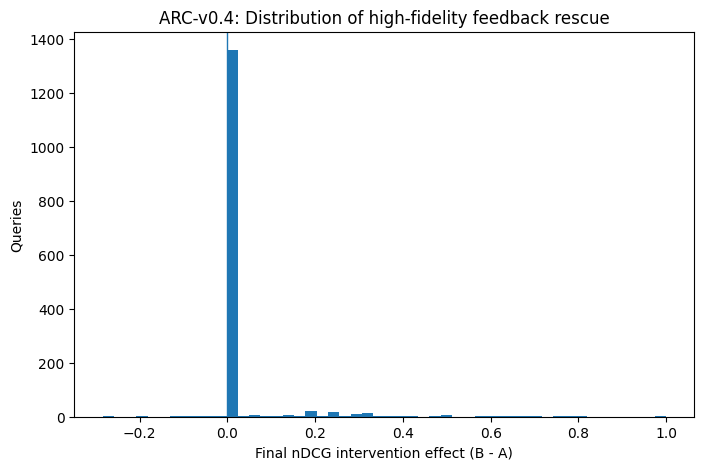

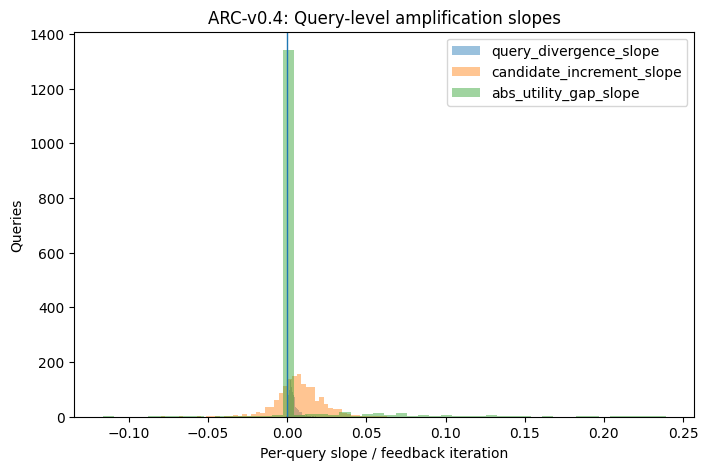

In [15]:
fig,ax=plt.subplots(figsize=(8,5))
ax.hist(
    query_effects["B_minus_A"],
    bins=50,
)
ax.axvline(0,linewidth=1)
ax.set_xlabel("Final nDCG intervention effect (B - A)")
ax.set_ylabel("Queries")
ax.set_title("ARC-v0.4: Distribution of high-fidelity feedback rescue")
plt.show()

fig,ax=plt.subplots(figsize=(8,5))

for metric in slope_metrics:
    ax.hist(
        query_slopes[metric],
        bins=50,
        alpha=.45,
        label=metric,
    )

ax.axvline(0,linewidth=1)
ax.set_xlabel("Per-query slope / feedback iteration")
ax.set_ylabel("Queries")
ax.set_title("ARC-v0.4: Query-level amplification slopes")
ax.legend()
plt.show()


## 14. Final statistical gate

A strong mechanism result requires all of the following:

### Amplification
- query-state slope mean > 0, 95% bootstrap CI excludes 0;
- baseline-normalized candidate slope mean > 0, CI excludes 0;
- absolute utility-gap slope mean > 0, CI excludes 0;
- Holm-adjusted randomization \(p<0.05\) for all three.

### Intervention
- query-level \(B-A>0\);
- 95% bootstrap CI excludes 0;
- paired sign-flip \(p<0.05\);
- positive effect is not explained by only one or two extreme observations.

The last criterion is diagnostic rather than arbitrary:
we flag severe concentration if the largest 1% of positive responders explain >75% of
all positive effect mass.


In [16]:
slope_pass = bool(
    (
        primary_slope_df["mean"] > 0
    ).all()
    and (
        primary_slope_df["ci_low"] > 0
    ).all()
    and (
        primary_slope_df["holm_p"] < .05
    ).all()
)

intervention_pass = bool(
    intervention_primary["mean"] > 0
    and intervention_primary["ci_low"] > 0
    and intervention_primary["randomization_p"] < .05
)

not_extreme_concentration = bool(
    np.isnan(intervention_primary["top1pct_mass"])
    or intervention_primary["top1pct_mass"] < .75
)

methods_positive = bool(
    (method_intervention_df["mean"] > 0).all()
)

print("=== ARC-v0.4 STATISTICAL MECHANISM AUDIT ===")
print()
print("AMPLIFICATION")
display(
    primary_slope_df[
        [
            "metric","mean","ci_low","ci_high",
            "randomization_p","holm_p",
            "fraction_positive"
        ]
    ]
)

print()
print("INTERVENTION")
print(
    f"Query-level B-A mean             : "
    f"{intervention_primary['mean']:+.6f}"
)
print(
    f"95% bootstrap CI                 : "
    f"[{intervention_primary['ci_low']:+.6f}, "
    f"{intervention_primary['ci_high']:+.6f}]"
)
print(
    f"Sign-flip p                      : "
    f"{intervention_primary['randomization_p']:.6g}"
)
print(
    f"Median effect                    : "
    f"{intervention_primary['median']:+.6f}"
)
print(
    f"Positive / zero / negative       : "
    f"{intervention_primary['fraction_positive']:.3%} / "
    f"{intervention_primary['fraction_exact_zero']:.3%} / "
    f"{intervention_primary['fraction_negative']:.3%}"
)
print(
    f"Top 1% positive-effect mass      : "
    f"{intervention_primary['top1pct_mass']:.3%}"
)
print(
    f"Effective positive contributors  : "
    f"{intervention_primary['effective_positive_n']:.1f}"
)
print()
print("Method-specific:")
display(
    method_intervention_df[
        [
            "method","mean","ci_low","ci_high",
            "randomization_p","fraction_positive",
            "top1pct_mass"
        ]
    ]
)

print()
print("GATES")
print("Query-level amplification inference :",slope_pass)
print("Intervention inference              :",intervention_pass)
print("Not dominated by top 1%            :",not_extreme_concentration)
print("Both feedback methods positive      :",methods_positive)
print()

if (
    slope_pass
    and intervention_pass
    and not_extreme_concentration
    and methods_positive
):
    decision = (
        "STATISTICAL MECHANISM PASS: amplification remains positive after query-level "
        "inference, candidate divergence remains positive after subtracting the large t=0 "
        "retriever mismatch, and the SQ8-feedback intervention has a statistically stable "
        "paired benefit. Proceed to cross-dataset replication."
    )

elif slope_pass and intervention_pass:
    decision = (
        "CORE EFFECT PASS, DISTRIBUTION WARNING: the paired amplification/intervention effects "
        "are statistically supported, but the intervention is highly concentrated or not "
        "consistent across feedback operators. Cross-dataset replication is justified only "
        "with the sparse-rescue framing made explicit."
    )

elif slope_pass:
    decision = (
        "AMPLIFICATION PASS, INTERVENTION FAIL: trajectory divergence is statistically robust, "
        "but the high-fidelity-feedback intervention is not stable enough to support the "
        "feedback-contamination causal mechanism."
    )

else:
    decision = (
        "STATISTICAL MECHANISM NO-GO: the v0.3 aggregate result does not survive query-level "
        "statistical auditing. Do not expand this mechanism claim across datasets."
    )

print("DECISION:",decision)


=== ARC-v0.4 STATISTICAL MECHANISM AUDIT ===

AMPLIFICATION


,metric,mean,ci_low,ci_high,randomization_p,holm_p,fraction_positive
0,query_divergence_slope,0.003694,0.003556,0.003836,0.00001,0.00003,0.995333
1,candidate_increment_slope,0.007529,0.006786,0.008263,0.00001,0.00003,0.734667
2,abs_utility_gap_slope,0.005672,0.004311,0.007085,0.00001,0.00003,0.094667



INTERVENTION
Query-level B-A mean             : +0.024726
95% bootstrap CI                 : [+0.019469, +0.030252]
Sign-flip p                      : 9.9999e-06
Median effect                    : +0.000000
Positive / zero / negative       : 8.800% / 90.133% / 1.067%
Top 1% positive-effect mass      : 5.165%
Effective positive contributors  : 87.1

Method-specific:


,method,mean,ci_low,ci_high,randomization_p,fraction_positive,top1pct_mass
0,mean,0.011174,0.006550,0.016123,0.00001,0.036667,0.049772
1,softmax,0.038279,0.030827,0.046111,0.00001,0.082667,0.034287



GATES
Query-level amplification inference : True
Intervention inference              : True
Not dominated by top 1%            : True
Both feedback methods positive      : True

DECISION: STATISTICAL MECHANISM PASS: amplification remains positive after query-level inference, candidate divergence remains positive after subtracting the large t=0 retriever mismatch, and the SQ8-feedback intervention has a statistically stable paired benefit. Proceed to cross-dataset replication.


## 15. Save audit evidence


In [17]:
query_method_slopes.to_csv(
    OUT/"query_method_amplification_slopes.csv",
    index=False,
)

query_slopes.to_csv(
    OUT/"query_pooled_amplification_slopes.csv",
    index=False,
)

primary_slope_df.to_csv(
    OUT/"primary_amplification_inference.csv",
    index=False,
)

method_slope_df.to_csv(
    OUT/"method_specific_amplification.csv",
    index=False,
)

effects.to_csv(
    OUT/"query_method_intervention_effects.csv",
    index=False,
)

query_effects.to_csv(
    OUT/"query_pooled_intervention_effects.csv",
    index=False,
)

method_intervention_df.to_csv(
    OUT/"method_specific_intervention.csv",
    index=False,
)

round_df.to_csv(
    OUT/"marginal_round_amplification.csv",
    index=False,
)

if len(severity_bins):
    severity_bins.to_csv(
        OUT/"harm_severity_rescue_bins.csv",
        index=False,
    )

report = {
    "source_v03":str(V03_RUN),
    "protocol":{
        "primary_unit":"query",
        "bootstrap_samples":BOOTSTRAP_SAMPLES,
        "randomization_samples":RANDOMIZATION_SAMPLES,
        "candidate_metric":"D_C(t)-D_C(0)",
        "test_retrieval_performed":False,
    },
    "primary_amplification":
        primary_slope_df.to_dict(orient="records"),
    "intervention_primary":
        intervention_primary,
    "intervention_distribution":
        distribution_summary,
    "rescue_exploratory":
        rescue_summary,
    "harm_rescue_correlation":pearson,
    "method_intervention":
        method_intervention_df.to_dict(orient="records"),
    "gates":{
        "slope_pass":slope_pass,
        "intervention_pass":intervention_pass,
        "not_extreme_concentration":not_extreme_concentration,
        "methods_positive":methods_positive,
    },
    "decision":decision,
}

(OUT/"report.json").write_text(
    json.dumps(
        report,
        indent=2,
        default=float,
    ),
    encoding="utf-8",
)

print("Saved:",OUT)
print("Report:",OUT/"report.json")


Saved: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/statistical-mechanism-audit-v04-20260815-202739
Report: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/statistical-mechanism-audit-v04-20260815-202739/report.json
